# Classificazione dell'Ironia nei Tweet

Questo notebook implementa un modello di classificazione binaria per prevedere se un tweet è ironico o meno.

## Descrizione del Task

**Obiettivo:** Costruire e addestrare un modello di Machine Learning per classificare un tweet come ironico o non ironico.

**Classi:**

*   Ironico
*   Non Ironico

**Metrica di Valutazione:** F1-Score

## Dataset

Il dataset è composto dai seguenti file:

*   **Train_Text.txt:** Tweet in inglese con le relative etichette di ironia.
*   **Test_Text.txt:** Tweet in inglese senza etichette (da classificare).
*   **Val_Text.txt:** Tweet in inglese per la validazione.
*   **Val_Labels.txt:** Etichette di ironia corrispondenti a Val_Text.txt.
*   **Mapping.txt:** Mappatura tra etichette numeriche e categorie di ironia (Ironico/Non Ironico).
*   **Example_Prediction_Submission.csv:** Un esempio del formato del file di sottomissione.

## 1. Installazioni Python

In [76]:
!pip install pandas numpy torch transformers scikit-learn emoji emot wordsegment

## 2. Import Python

In [77]:
import pandas as pd
import numpy as np
import torch
from torch.optim import AdamW, lr_scheduler
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
from sklearn.metrics import f1_score, accuracy_score
from torch import nn
import emoji
from emot import emot
import re
from collections import defaultdict
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import random
from nltk.tokenize import TweetTokenizer
import wordsegment
from sklearn.model_selection import ParameterGrid

seed_value = 42

random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value) # Se stai usando la GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# Controlla se la GPU è disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizzato: {device}")

Dispositivo utilizzato: cuda


## 3. Data Loading e Preprocessing

### 3.1. Helper Functions

Definizione delle helper functions per caricare i dati dai file:

In [78]:
def read_lines(filepath):
    # Legge le linee da un file saltanto le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines() if line.strip()]

def read_labels(filepath):
    # Legge le etichette intere da un file saltando le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines() if line.strip()]

def load_abbreviations(file_path="irony/abbreviations.json"):
    with open(file_path, "r", encoding="utf-8") as file:
      abbreviations = json.load(file)
    lowercase_abbreviations = {key.lower(): value for key, value in abbreviations.items()}
    return lowercase_abbreviations

### 3.2. Data Loading

Carica i dati dai file di testo forniti:

In [79]:
# File paths
train_text_path = "/content/train_text.txt"
train_labels_path = "/content/train_labels.txt"
val_text_path = "/content/val_text.txt"
val_labels_path = "/content/val_labels.txt"
test_text_path = "/content/test_text.txt"
mapping_path = "/content/mapping.txt"

# Load data
train_texts = read_lines(train_text_path)
val_texts = read_lines(val_text_path)
test_texts = read_lines(test_text_path)

train_labels = read_labels(train_labels_path)
val_labels = read_labels(val_labels_path)

# Load mapping
mapping = pd.read_csv(mapping_path, header=None, index_col=0, sep="\t")[1].to_dict()
label_to_num = {v: k for k, v in mapping.items()}

print("Dati Caricati con Successo")
print(f"Numero di esempi di training: {len(train_texts)})")
print(f"Numero di esempi di validazione: {len(val_texts)}")
print(f"Numero di esempi di test: {len(test_texts)}")
print(f"Irony Mapping: {mapping}")

Dati Caricati con Successo
Numero di esempi di training: 2862)
Numero di esempi di validazione: 955
Numero di esempi di test: 784
Irony Mapping: {0: 'non_irony', 1: 'irony'}


### 3.3. Data Analysis e Preprocessing

#### 3.3.1 Distribuzione delle classi

Stampiamo alcuni esempi dei tweet, per capire meglio come vengono realizzati.

In [80]:
print("Tweet di esempio (train):")
for i in range(3):
    print(f"{i+1}. {train_texts[i]} (Label: {mapping[train_labels[i]]})")

print("\nTweet di esempio (validation):")
for i in range(3):
    print(f"{i+1}. {val_texts[i]} (Label: {mapping[val_labels[i]]})")

Tweet di esempio (train):
1. seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of my life (Label: irony)
2. look for the girl with the broken smile, ask her if she wants to stay while, and she will be loved. 💕🎵 (Label: non_irony)
3. Now I remember why I buy books online @user #servicewithasmile (Label: irony)

Tweet di esempio (validation):
1. #NBA players #NY support protests of #police killings/sure #money donations for #college WB coming (Label: irony)
2. A new year about to start|So many people came so many went|But always wat's gone is better. (Label: non_irony)
3. Obama's $1,176,120.90 in Taxpayer Funded Costs to Attend Political Fundraisers in Los Angeles, San Francisco (Label: irony)


Rappresentazione della distribuzione delle classi per mostrare se il dataset sia sbilanciato:

Distribuzione delle classi nel training set:
0    1417
1    1445
Name: count, dtype: int64


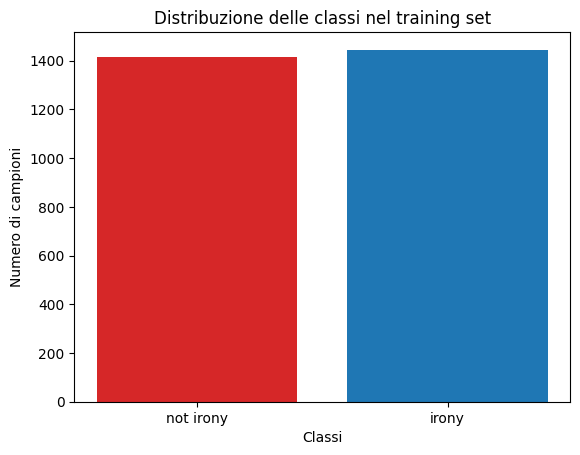

In [81]:
labels_series = pd.Series(train_labels)

# Conta il numero di campioni per ciascuna classe
class_distribution = labels_series.value_counts().sort_index()
print("Distribuzione delle classi nel training set:")
print(class_distribution)

label_names = ['not irony', 'irony']
counts = [class_distribution.get(i, 0) for i in range(len(label_names))]
plt.bar(label_names, counts, color=['tab:red', 'tab:blue'])
plt.xlabel("Classi")
plt.ylabel("Numero di campioni")
plt.title("Distribuzione delle classi nel training set")
plt.show()

#### 3.3.2. Preprocessing sui Tweet

Per il preprocessing dei tweet si sono applicate una serie di trasformazioni che rendono il testo più facilmente comprensibile per il modello.

* **Normalizzazione del Testo:**
    * Se una ettera si ripete più di tre volte, viene ridotta a due (es. `soooo` → `soo`).
  
    * Gli URL e le menzioni vengono sostituiti con `HTTPURL` e `@USER`,  rispettivamente, perché il tokenizzatore del modello `bertweet`, da noi impiegato, conosce i token per le menzioni e per gli URL in questo modo.

    * I segni di punteggiatura ripetuti più di due volte vengono ridotti a due (es. `!!!!!` → `!!`).
  
*   **Conversione delle Emoji in Testo:** Le emoji vengono convertite nei rispettivi codici come `😊` -> `:smile:`.

*   **Gestione degli hashtag:**
    * Se un hashtag (#BestDayEver) è presente nel vocabolario del tokenizer, viene mantenuto inalterato.
    * Se l’hashtag non è nel vocabolario, viene segmentato in parole separate (es. #BestDayEver → #Best Day Ever).

*   **Pulizia Spazi Extra:** Si rimuovono i eventuali spazi extra tra le parole.

In [82]:
# Carica il tokenizer di BERTweet
model_name = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
vocab = tokenizer.get_vocab()

# Tokenizer per i tweet
tweetTokenizer = TweetTokenizer(preserve_case=True, reduce_len=False)
wordsegment.load()
emot_processor = emot()

# Riduce ripetizioni di lettere solo se >3
def reduce_repetitions(token):
    return re.sub(r"(.)\1{3,}", r"\1\1", token)

# Normalizzazione avanzata
def normalize_token(token):
    if re.match(r"^@[A-Za-z0-9_]+$", token):
        return "@USER"
    elif token.lower().startswith(("http", "www")):
        return "HTTPURL"
    elif emoji.is_emoji(token):
        return emoji.demojize(token)  # Convertiamo le emoji in formato testuale
    else:
        return reduce_repetitions(token)  # Normalizziamo solo ripetizioni eccessive

# Gestione degli hashtag: segmentiamo solo quelli fuori vocabolario
def process_hashtag(match):
    hashtag = match.group(1)
    if hashtag in vocab:
        return "#" + hashtag
    segmented = wordsegment.segment(hashtag)
    return "#" + " ".join(segmented)

# Preprocessa il tweet
def preprocess_tweet(tweet):
    tweet = re.sub(r"#(\w+)", process_hashtag, tweet)  # Segmenta solo hashtag non nel vocabolario
    tokens = tweetTokenizer.tokenize(tweet)  # Tokenizza il tweet
    tweet = " ".join([normalize_token(token) for token in tokens])  # Normalizza

    # Punteggiatura: riduciamo ripetizioni estreme
    tweet = re.sub(r"([!?])\1{2,}", r"\1\1", tweet)

    # Rimuoviamo spazi multipli
    tweet = " ".join(tweet.split())

    return tweet

# Esempio di utilizzo
tweet_example = "OH WOW I'm soooo happy!!!!!!! don't Check this out: https://example.com @user #BestDayEver 😂🙃"
processed_tweet = preprocess_tweet(tweet_example)
print(processed_tweet)


OH WOW I'm soo happy ! ! ! don't Check this out : HTTPURL @USER #best day ever :face_with_tears_of_joy: :upside-down_face:


## 4. Setup del Modello

### 4.1 Inizializzazione del Tokenizer

Alcune delle emoji presenti nei tweet non sono contenute all'interno del vocabolario del tokenizzatore. L'aggiunta delle emoji mancanti, sottoforma testuale, ha portato dei miglioramenti in fase di validazione.

Analizziamo la distribuzione delle lunghezze dei testi tokenizzati per determinare un valore ottimale di `max_length`, il parametro che definisce la lunghezza massima delle sequenze per il modello.

*   **Calcolo della distribuzione delle lunghezze:** Per ogni testo presente nei dataset train, validation e test, viene calcolata la lunghezza della sequenza risultante dopo la tokenizzazione.

*   **Determinazione della lunghezza massima (max_length)**
    * Il valore iniziale di `max_length` è il massimo valore trovato in `token_lenghts`, ma non può superare il limite massimo del modello `model_max_len`.
    * Quindi si verifica che il valore finale di `max_length` non superi il limite del modello.

*   **Visualizzazione della distribuzione**
    * Due linee verticali indicano:
        * **Linea rossa tratteggiata:** Valore finale scelto per `max_length`.
        * **Linea arancione punteggiata:** Lunghezza massima consentita dal modello.

In [83]:
textual_emoji_tokens = set()
for text in train_texts:
    #se non usiamo berttweet allora aggiungere un token per ogni emoticon che troviamo nel train
    # Estrae le emoji presenti nel testo
    for emo in emoji.distinct_emoji_list(text):
        text_emoji = emoji.demojize(emo)
        if text_emoji not in vocab:
            # Converte l'emoji in forma testuale, ad es. "😊" -> ":smiling_face:"
            textual_emoji_tokens.add(text_emoji)
textual_emoji_tokens = list(textual_emoji_tokens)
print(textual_emoji_tokens)
tokenizer.add_tokens(textual_emoji_tokens)
print(f"Added {len(textual_emoji_tokens)} textual emoji tokens to the tokenizer.")

print("Tokenizer Initialized")

[':person_taking_bath:', ':hollow_red_circle:', ':fire_engine:', ':bust_in_silhouette:', ':violin:', ':women_holding_hands:', ':SOON_arrow:', ':weary_cat:', ':ambulance:', ':electric_plug:', ':enraged_face:', ':frog:', ':mouse:', ':water_pistol:', ':ZZZ:', ':police_car:']
Added 16 textual emoji tokens to the tokenizer.
Tokenizer Initialized


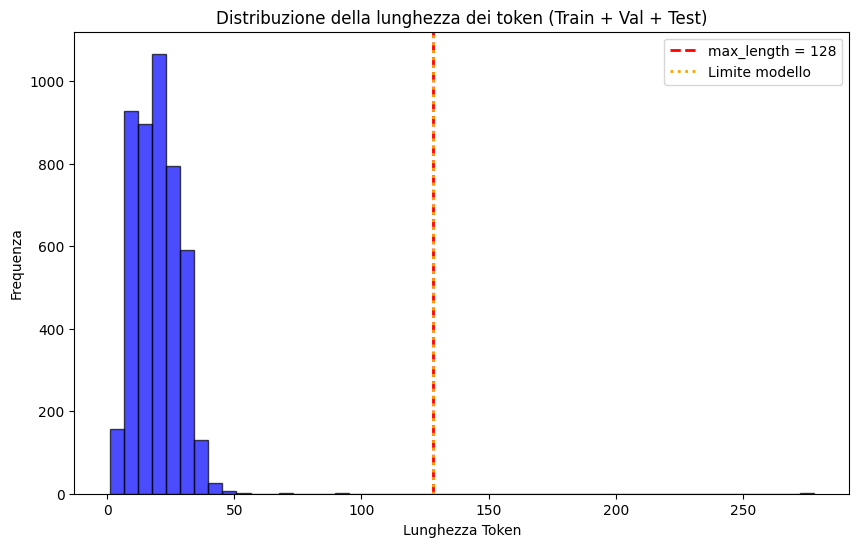

Valore scelto per max_length: 128
Massimo originale nel dataset: 278


In [84]:
# Calcoliamo la distribuzione delle lunghezze tokenizzate per tutti i set
token_lengths = [len(tokenizer.tokenize(t)) for t in train_texts + val_texts + test_texts]

model_max_len = 128
# Impostiamo max_length come il valore massimo della distribuzione
max_len = min(max(token_lengths), model_max_len)

# Visualizzazione della distribuzione
plt.figure(figsize=(10, 6))
plt.hist(token_lengths, bins=50, alpha=0.7, color='b', edgecolor='black')
plt.axvline(max_len, color='r', linestyle='dashed', linewidth=2, label=f"max_length = {max_len}")
plt.axvline(model_max_len, color='orange', linestyle='dotted', linewidth=2, label="Limite modello")
plt.title("Distribuzione della lunghezza dei token (Train + Val + Test)")
plt.xlabel("Lunghezza Token")
plt.ylabel("Frequenza")
plt.legend()
plt.show()

print(f"Valore scelto per max_length: {max_len}")
print(f"Massimo originale nel dataset: {max(token_lengths)}")

### 4.2 Classe Dataset

Questa classe rende il dataset compatibile con PyTorch, viene utilizzato per gestire i dati di input durante l'addestramento e la valutazione del modello.

1. **`__init__`**
Inizializza il dataset con:
    * `texts`: Lista dei tweet.
    * `labels`: Etichette corrispondenti.
    * `tokenizer`: Tokenizer pre-addestrato per elaborare il testo.
    * `max_len`: Lunghezza massima della sequenza tokenizzata.

2. **`__len__`**
Restituisce la cardinalità del dataset.

3. **`__getitem__`**
Recupera un elemento in base all'indice `idx`:
    * **Preprocessing del tweet:** Il testo viene processato.
    * **Gestione dell'etichetta:** Viene recuperata l'etichetta corrispondente.
    * **Tokenizzazione:**
        * Il testo viene convertito in ID token con il tokenizer fornito.
        * Viene applicato il *padding* e *troncamento* per adattare ciascun token alla dimensione dell'ingresso del modello.
    * **Conversione in Tensori:**
        * Gli `input_ids` e `attention_mask` vengono restituiti in formato tensoriale.
        * L'etichetta viene convertita in tensore per essere compatibile con al funzione di perdita.

In [85]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        text = preprocess_tweet(text)

        label = self.labels[idx] if self.labels is not None else -1
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

### 4.3 Definizione del Modello

La scelta del modello è ricaduta su BertTweet poiché rappresenta il modello più indicato essendo pre-addestrato sui tweet in lingua inglese.

1. **`__init__`** Definisce la struttura del modello.

    * **Definizione del Classificatore**
    Il classificatore aggiunto alla testa del modello è del tipo *fully connected* costituito da:
        1. Dropout (`nn.Dropout()`): aiuta a ridurre l'overfitting.
        2. Layer Finale (`nn.Linear`): restituisce un logit per la classificazione binaria.

2. **`forward()`** Flusso dei dati attraverso la rete
    * Elabora gli input con il modello pre-addestrato.
    * Estrae il token CLS che rappresenta l'intera frase.
    * Passa il token CLS nel classificatore, ottenendo il valore logit per la classificazione.

In [ ]:
class IronyClassifier(nn.Module):
    def __init__(self, dropout, model_name, tokenizer):
        super(IronyClassifier, self).__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.base_model = AutoModel.from_pretrained(model_name, config=self.config)

        self.base_model.resize_token_embeddings(len(tokenizer))

        hidden_dim = self.base_model.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state_cls = outputs.last_hidden_state[:, 0, :]  # CLS token
        logits = self.classifier(last_hidden_state_cls)
        return logits


### 4.4 Inizializzazione del Modello

Si inizializza il modello e si stampa la propria architettura.

In [87]:
def print_model_summary(model):
    print("-"*89)
    print(f"| Layer Name                                              | # of Parameters | Trainable |")
    print("-"*89)
    total_num_trainable_params = 0
    for layer_name, layer_params in model.named_parameters():
        if layer_params.requires_grad:
            total_num_trainable_params += layer_params.numel()
        print(f"| {layer_name:<55} | {layer_params.numel():<15} | {str(layer_params.requires_grad):<9} |")
    print("-"*89)
    print(f"| Total # of Parameters: {total_num_trainable_params:<62} |" )
    print("-"*89)

print_model_summary(AutoModel.from_pretrained(model_name))

-----------------------------------------------------------------------------------------
| Layer Name                                              | # of Parameters | Trainable |
-----------------------------------------------------------------------------------------
| embeddings.word_embeddings.weight                       | 49152768        | True      |
| embeddings.position_embeddings.weight                   | 99840           | True      |
| embeddings.token_type_embeddings.weight                 | 768             | True      |
| embeddings.LayerNorm.weight                             | 768             | True      |
| embeddings.LayerNorm.bias                               | 768             | True      |
| encoder.layer.0.attention.self.query.weight             | 589824          | True      |
| encoder.layer.0.attention.self.query.bias               | 768             | True      |
| encoder.layer.0.attention.self.key.weight               | 589824          | True      |
| encoder.

## 5. Training e Validation

### 5.1. Classe per l'Early Stopping

Definisce la classe `EarlyStopping` per prevenire l'overfitting.

*   **`__init__`**
    * `patience`: Numero massimo di epoche consecutive senza miglioramenti prima di arrestare l'addestramento.
    * `min_delta`: Miglioramento minimo richiesto per considerare il modello migliorato.
    * `mode`: Imposta su *max* per massimizzare F1-score.
    * `counter`: Conta quante epoche consecutive non portano miglioramenti.
    * `best_score`: Inizializzato in questo caso a `-np.inf`.

*   **`__call__`**: Il metodo viene chiamato ad ogni epoca con il valore attuale della metrica.
    * Verifica il miglioramento se supera il `best_score` precedente di almeno un `min_delta`.
    * Interompe l'addestramento se si supera il valore di `patience` restituendo `True` altrimenti `False` proseguendo con il processo di addestramento.

In [88]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = -np.inf if mode == 'max' else np.inf

    def __call__(self, current_score):
        if self.mode == 'max':
            improvement = (current_score - self.best_score) > self.min_delta
        else:
            improvement = (self.best_score - current_score) > self.min_delta

        if improvement:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # Early stop
        return False

### 5.2. Funzioni per il Training e per l'Evaluation

Queste due funzioni gestiscono l'addestramento e la valutazione del modello di classificazione.


In [89]:
def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    predictions, targets = [], []
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss = loss_fn(outputs, labels.unsqueeze(1).float())
        total_loss += loss.item()

        # Calcolo delle previsioni (classe con la più alta probabilità dopo sigmoide)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        loss.backward()
        #faccio GRADIENT CLIPPING stabilizzo il modello
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())
    accuracy = accuracy_score(targets, predictions)
    return total_loss / len(data_loader), accuracy


def eval_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    predictions, targets = [], []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs, labels.unsqueeze(1).float())
            total_loss += loss.item()

            # Calcolo delle previsioni (classe con la più alta probabilità dopo sigmoide)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.cpu().numpy())
    f1 = f1_score(targets, predictions, average="macro")
    accuracy = accuracy_score(targets, predictions)
    return total_loss / len(data_loader), accuracy, f1

### 5.3 Training Loop con Validazione

In questa sezione viene addestrato l'ultima parte del modello per la classificazione su una griglia di iperparametri. Questo permette di addestrare il modello su tutte le combinazioni di iperparametri valutando quale combinazione utilizzata definisce il miglior modello, la ricerca si basa tenendo traccia del F1-score più alto ottenuto sul validation set.

Tuttavia, a causa dell'inizializzazione dei pesi e dello shuffle del data loader abbiamo optato, per l'addestramento, di utilizzare la configurazione degli iperparametri che ci ha restituito i risultati migliori (senza applicare la validazione).


In [ ]:
# Abbiamo effettuato la validazione su una sola combinazione poichè i risultati erano affetti dall'inizializzazione dei pesi
# e dallo shuffle del data loader
param_grid = {
    "learning_rate": [2e-5],
    "dropout": [0.2],
    "batch_size": [16]
}

param_grid = ParameterGrid(param_grid)

loss_fn = nn.BCEWithLogitsLoss().to(device)

best_val_loss = float("inf")
best_params = None
best_metrics_history_global = None
best_model_weights_global = None

epochs = 5

train_dataset = TweetDataset(train_texts, train_labels, tokenizer, max_len)
val_dataset = TweetDataset(val_texts, val_labels, tokenizer, max_len)
test_dataset = TweetDataset(test_texts, None, tokenizer, max_len)

for params in param_grid:
    torch.cuda.empty_cache()

    print(f"Validazione sui parametri: {params}\n")
    lowest_val_loss = float("inf")
    best_model_weights = None

    epoch_metrics = []

    learning_rate = params["learning_rate"]
    dropout = params["dropout"]
    batch_size = params["batch_size"]

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print("Data Loaders Pronti")
    model = IronyClassifier(dropout, model_name, tokenizer).to(device)
    early_stopping = EarlyStopping(patience=2, min_delta=0.005, mode='min')
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=1, verbose=True)

    epochs_progress = tqdm(range(epochs), desc='Training', unit='epoch')
    for epoch in epochs_progress:
        start_time = time.time()
        epochs_progress.set_description(f"Epoch {epoch+1}")

        train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc, val_f1 = eval_model(model, val_loader, loss_fn, device)

        scheduler.step(val_loss)

        epoch_time = time.time() - start_time

        epochs_progress.set_postfix({
            'Train Loss': f"{train_loss:.4f}",
            'Val Loss': f"{val_loss:.4f}",
            'Time': f"{epoch_time:.1f}s"
        })

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Tempo impiegato: {epoch_time:.1f} secondi")

        epoch_metrics.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        if val_loss < lowest_val_loss - early_stopping.min_delta:
            lowest_val_loss = val_loss
            best_metrics_history = epoch_metrics.copy()
            best_model_weights = model.state_dict().copy()
            print(f"Nuova miglior Val Loss: {lowest_val_loss:.4f}")

        if early_stopping(val_loss):
            print(f"Early stopping attivato. Miglior Val Loss: {lowest_val_loss:.4f}")
            break

    if lowest_val_loss < best_val_loss:
        best_val_loss = lowest_val_loss
        best_params = params
        best_metrics_history_global = best_metrics_history
        best_model_weights_global = best_model_weights
        print(f"Nuova miglior Val Loss globale: {best_val_loss:.4f}")

print("Training Completato")
print(f"\nParametri Migliori: {best_params}")
print(f"Miglior Val Loss: {best_val_loss:.4f}")

torch.save(best_model_weights_global, "best_model_weights_irony.pt")
print("Modello migliore salvato")


Validazione sui parametri: {'batch_size': 16, 'dropout': 0.2, 'learning_rate': 2e-05}

Data Loaders Pronti


Epoch 2:  20%|██        | 1/5 [01:12<04:51, 72.96s/epoch, Train Loss=0.6058, Val Loss=0.5240, Time=73.0s]


Epoch 1/5
Train Loss: 0.6058 | Train Acc: 0.6565
Val Loss: 0.5240 | Val Acc: 0.7497 | Val F1: 0.7492
Tempo impiegato: 73.0 secondi
Nuova miglior Val Loss: 0.5240


Epoch 3:  40%|████      | 2/5 [02:25<03:37, 72.48s/epoch, Train Loss=0.4457, Val Loss=0.4921, Time=72.1s]


Epoch 2/5
Train Loss: 0.4457 | Train Acc: 0.8022
Val Loss: 0.4921 | Val Acc: 0.7707 | Val F1: 0.7667
Tempo impiegato: 72.1 secondi
Nuova miglior Val Loss: 0.4921


Epoch 4:  60%|██████    | 3/5 [03:38<02:25, 72.91s/epoch, Train Loss=0.2901, Val Loss=0.5455, Time=73.4s]


Epoch 3/5
Train Loss: 0.2901 | Train Acc: 0.8896
Val Loss: 0.5455 | Val Acc: 0.7770 | Val F1: 0.7734
Tempo impiegato: 73.4 secondi


Epoch 4:  60%|██████    | 3/5 [04:50<03:13, 96.85s/epoch, Train Loss=0.1941, Val Loss=0.7983, Time=72.0s]



Epoch 4/5
Train Loss: 0.1941 | Train Acc: 0.9420
Val Loss: 0.7983 | Val Acc: 0.7686 | Val F1: 0.7661
Tempo impiegato: 72.0 secondi
Early stopping attivato. Miglior Val Loss: 0.4921
Nuova miglior Val Loss globale: 0.4921
Training Completato

Parametri Migliori: {'batch_size': 16, 'dropout': 0.2, 'learning_rate': 2e-05}
Miglior Val Loss: 0.4921
Modello migliore salvato


Si continua ad addestrare sul modello migliore ottenuto in validazione per 10 epoche ulteriori per provare a vedere se riesce a generalizzare o overfitta:

In [91]:
model = IronyClassifier(best_params["dropout"], model_name, tokenizer).to(device)

# Carica i pesi salvati
best_model_path = "best_model_weights_irony.pt"
model.load_state_dict(torch.load(best_model_path, map_location=device))

additional_epochs = 5
additional_epoch_metrics = []  # Lista per salvare le metriche delle epoche addizionali

# Riutilizzo dei dataset e ricreazione dei DataLoader con il batch size dei migliori iperparametri
train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params["batch_size"], shuffle=False)

# Reinizializza ottimizzatore e scheduler per le nuove epoche
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=best_params["learning_rate"])

scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=1, verbose=True)

print("\n=== Continuazione dell'addestramento sul miglior modello per ulteriori 10 epoche ===\n")
epochs_progress = tqdm(range(additional_epochs), desc='Training', unit='epoch')
print(f"val_loss di partenza{best_val_loss:.4f}\n")
best_model_weights = None


for epoch in epochs_progress:
    start_time = time.time()
    epochs_progress.set_description(f"Epoch {epoch+1}")

    # Addestramento
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)

    # Validazione
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, loss_fn, device)

    epoch_time = time.time() - start_time

    # Aggiorna la descrizione della barra di progresso
    epochs_progress.set_postfix({
        'Train Loss': f"{train_loss:.4f}",
        'Val Loss': f"{val_loss:.4f}",
        'Time': f"{epoch_time:.1f}s"
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1:{val_f1:.4f}")

    additional_epoch_metrics.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    scheduler.step(val_loss)


    if val_loss < best_val_loss - 0.005:
        best_val_loss = val_loss
        best_model_weights = model.state_dict().copy()
        print(f"Nuova miglior Val Loss globale: {best_val_loss:.4f}")

if best_model_weights is not None:
    torch.save(best_model_weights, "best_model_weights_irony.pt")

model = IronyClassifier(best_params["dropout"], model_name, tokenizer).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))

<ipython-input-91-3f948012afe6>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))



=== Continuazione dell'addestramento sul miglior modello per ulteriori 10 epoche ===



Epoch 1:   0%|          | 0/5 [00:00<?, ?epoch/s] 

val_loss di partenza0.4921



Epoch 2:  20%|██        | 1/5 [01:12<04:49, 72.36s/epoch, Train Loss=0.1461, Val Loss=0.9374, Time=72.4s]

...

Train Loss: 0.0272 | Train Acc: 0.9955
Val Loss: 1.2043 | Val Acc: 0.7665 | Val F1:0.7661


Epoch 5: 100%|██████████| 5/5 [05:59<00:00, 71.96s/epoch, Train Loss=0.0220, Val Loss=1.2499, Time=71.8s]


Train Loss: 0.0220 | Train Acc: 0.9962
Val Loss: 1.2499 | Val Acc: 0.7675 | Val F1:0.7674


<ipython-input-91-3f948012afe6>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


<All keys matched successfully>

Rappresentazione grafica sulle metriche ottenute.

*   **Grafico sulla sinistra:** rappresenta la differenza tra gli andamenti delle `Loss` e delle `Accuracy`.
*   **Grafico sulla destra:** rappresenta `F1-score` ottenuto in validazione.
*   **Linea verticale:** indica l'inizio dell'andamento ottenuto sul training per le 10 epoche aggiuntive.

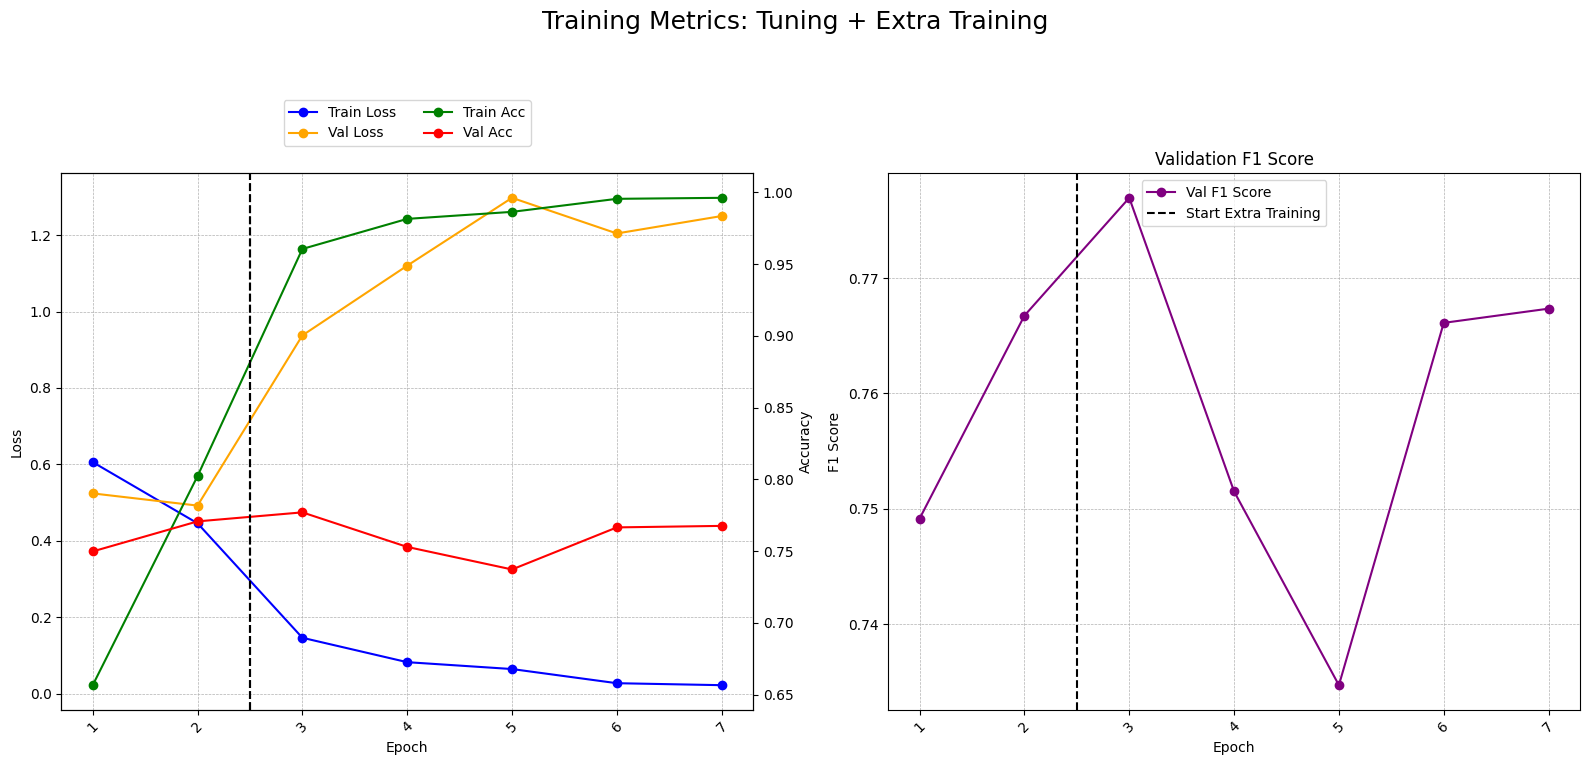

In [92]:
# Funzione per convertire un valore in float se è un tensore
def to_float(x):
    return x.cpu().item() if torch.is_tensor(x) else x

# Combiniamo le metriche della fase di tuning e quelle addizionali
all_epochs = best_metrics_history_global + additional_epoch_metrics
epochs_range = list(range(1, len(all_epochs) + 1))

# Creiamo un dizionario che contiene le metriche da plottare
metrics = {
    'train_loss': [to_float(m["train_loss"]) for m in all_epochs],
    'val_loss':   [to_float(m["val_loss"])   for m in all_epochs],
    'train_acc':  [to_float(m["train_acc"])  for m in all_epochs],
    'val_acc':    [to_float(m["val_acc"])    for m in all_epochs],
    'val_f1':     [to_float(m["val_f1"])     for m in all_epochs]
}

# Determiniamo il punto in cui inizia l'extra training
# Supponiamo che best_metrics_history_global contenga le metriche della fase di tuning
tuning_epochs = len(best_metrics_history_global)
extra_start = tuning_epochs + 0.5

# Creiamo una figura con 2 subplot affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

# Subplot sinistro: Loss e Accuracy
# Plottiamo loss (train e validation) sull'asse principale
ax1.plot(epochs_range, metrics['train_loss'], label="Train Loss", marker='o', color='blue')
ax1.plot(epochs_range, metrics['val_loss'], label="Val Loss", marker='o', color='orange')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.set_xticks(epochs_range)  # Mostriamo ogni epoca
ax1.tick_params(axis='x', rotation=45)

# Plottiamo l'accuracy su un asse secondario
ax1_acc = ax1.twinx()
ax1_acc.plot(epochs_range, metrics['train_acc'], label="Train Acc", marker='o', color='green')
ax1_acc.plot(epochs_range, metrics['val_acc'], label="Val Acc", marker='o', color='red')
ax1_acc.set_ylabel("Accuracy")

# Combiniamo le legende di entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_acc.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# Aggiungiamo la linea verticale che indica l'inizio dell'extra training
ax1.axvline(x=extra_start, color='black', linestyle='--', label="Start Extra Training")
ax1_acc.axvline(x=extra_start, color='black', linestyle='--')

# Subplot destro: Validation F1 Score
ax2.plot(epochs_range, metrics['val_f1'], label="Val F1 Score", marker='o', color='purple')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Score")
ax2.set_title("Validation F1 Score")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.set_xticks(epochs_range)  # Mostriamo ogni epoca
ax2.tick_params(axis='x', rotation=45)
ax2.axvline(x=extra_start, color='black', linestyle='--', label="Start Extra Training")
ax2.legend(loc='upper center')

# Layout finale e visualizzazione
plt.suptitle("Training Metrics: Tuning + Extra Training", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Prediction

### 6.1. Funzione per la predizione

Definizione di una funzione per creare le predizioni sul test set:

In [93]:
def predict_irony(model, data_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            predictions.extend(preds.cpu().numpy())
    return predictions

### 6.2. Predizioni Ottenute

Genera le predizioni per il test set:

In [94]:
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
test_predictions = predict_irony(model, test_loader, device)

## 7. Submission

### 7.1. Crea il Submission CSV

Crea un file CSV con le predizioni nel formato richiesto:

In [95]:
submission_df = pd.DataFrame(test_predictions)
submission_df.to_csv("irony_predictions.csv", index=False, header=False)
print("Predizioni memorizzate in predictions.csv")

Predizioni memorizzate in predictions.csv
